# 라이브러리 불러오기

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torchvision 
import torchvision.transforms as transforms 
import os 
import torchvision.utils 
from PIL import Image

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 데이터셋 가져오기

In [2]:
# 데이터 전처리 코드
# 정규화
transform = transforms.Compose([
    transforms.ToTensor(), # 이미지 행렬을 Pytorch맞는 형태로 형변환 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 평균, 표준편차 ==> RGB 채널별 정규화
])

# 훈련데이터
trainset = torchvision.datasets.CIFAR10(root='./data', 
                                        train=True, 
                                        download=True, 
                                        transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, 
    batch_size=64,                # 배치 크기 
    shuffle=True,                 # 데이터 섞기
    num_workers=2                 # 데이터 로딩에 사용할 프로세스 수
)

# 테스트 데이터
testset = torchvision.datasets.CIFAR10(root='./data', 
                                        train=False, 
                                        download=True, 
                                        transform=transform)

testloader = torch.utils.data.DataLoader(
    testset, 
    batch_size=64,                # 배치 크기 
    shuffle=False,                # 데이터 섞기
    num_workers=2                 # 데이터 로딩에 사용할 프로세스 수
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:42<00:00, 4.06MB/s]


In [3]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

# 데이터 시각화

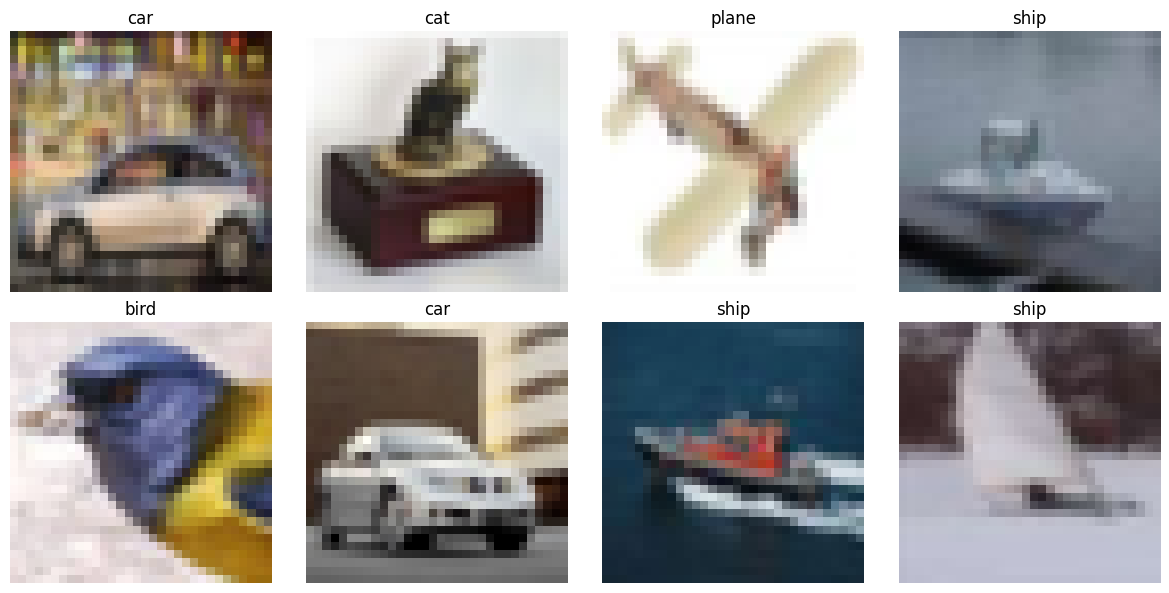

이미지 크기: torch.Size([3, 32, 32])
배치 크기: 64
채널 수: 3
이미지 높이: 32
이미지 너비: 32


In [4]:
import matplotlib.pyplot as plt 
import numpy as np

# 클래스 이름 정의
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 이미지 시각화 함수
def imshow(img):
    img = img / 2 + 0.5     # 정규화 해제
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# 학습 데이터의 일부 이미지 시각화
dataiter = iter(trainloader)
images, labels = next(dataiter)

# 이미지 그리드 생성
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(8):
    imshow(images[i])
    axes[i].imshow(np.transpose(images[i].numpy() / 2 + 0.5, (1, 2, 0)))
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# 이미지 통계 정보 출력
print(f"이미지 크기: {images[0].shape}")
print(f"배치 크기: {images.size(0)}")
print(f"채널 수: {images.size(1)}")
print(f"이미지 높이: {images.size(2)}")
print(f"이미지 너비: {images.size(3)}")

# 모델 만들기

In [5]:
classes = trainset.classes # 클래스 이름 저장

# CNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # 첫번째 컨볼루션 레이어
        self.conv1 = nn.Conv2d(
            in_channels=3,           # RGB 3채널 이미지와 관련된 기본 상식
            out_channels=32,         # 32개의 필터 (CNN 이론)
            kernel_size=3,           # 3x3 커널 (CNN 이론)         
            padding=1                # 패딩으로 크기 유지 (CNN 이론)
        )
        self.pool = nn.MaxPool2d(2, 2) # 2 x 2 최대 풀링 (CNN 이론)

        # 두번째 컨볼루션 레이어
        self.conv2 = nn.Conv2d(
            in_channels=32,          # 1번째 레이어의 out_channel이 32
            out_channels=64,         # 64개의 필터 (CNN 이론)
            kernel_size=3,           # 3x3 커널 (CNN 이론)         
            padding=1                # 패딩으로 크기 유지 (CNN 이론)
        )

        # 완전연결 레이어, 정형 데이터 분류모형 알고리즘과 똑같음
        self.fc1 = nn.Linear(64 * 8 * 8, 128)    # 128개의 뉴런으로 만들겠음
        self.fc2 = nn.Linear(128, 10)            # 10개 클래스로 출력
        
    def forward(self, x):
        # 첫번째 컨볼루션 블록
        x = self.pool(F.relu(self.conv1(x))) # Conv ==> Relu ==> Pool 

        # 두번째 컨볼루션 블록
        x = self.pool(F.relu(self.conv2(x))) # Conv ==> Relu ==> Pool

        # Flatten 및 완전연결 레이어
        x = x.view(-1, 64 * 8 * 8)           # 2D --> 1D 변환 
        x = F.relu(self.fc1(x))              # 첫번째 FC + ReLu
        x = self.fc2(x)                      # 최종 출력
        return x


## 모델 초기화 

In [6]:
# 모델 초기화 및 학습 설정
model = SimpleCNN().to(device)  # 모델을 GPU로 이동
criterion = nn.CrossEntropyLoss()  # 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # 옵티마이저

## 모델 학습

In [7]:
for epoch in range(1): # 1 에포크 학습
    running_loss = 0.0 
    for i, (inputs, labels) in enumerate(trainloader):

        # 데이터를 GPU로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 순전파 및 역전파 
        optimizer.zero_grad() # 그래디언트 초기화 
        outputs = model(inputs) # 순전파 
        loss = criterion(outputs, labels) # 손실계산 
        loss.backward() # 역전파 
        optimizer.step() # 가중치 업데이트 
        
        # 손실 기록 및 출력
        running_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f"[{epoch+1}, {i+1:5d}] loss: {running_loss / 100:.3f}")
            running_loss = 0.0

print("학습 완료 ✅")

[1,   100] loss: 1.820
[1,   200] loss: 1.513
[1,   300] loss: 1.352
[1,   400] loss: 1.284
[1,   500] loss: 1.207
[1,   600] loss: 1.174
[1,   700] loss: 1.119
학습 완료 ✅


# 모델 평가

In [8]:
model.eval() # 평가 모드로 전환 
correct = 0
total = 0
with torch.no_grad(): # 그래디언트 계산 비활성화
    for data in testloader: 
        images, labels = data 
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # 가장 높은 확률의 클래스 선택 
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(correct / total)

0.6296


# 모델 저장

In [9]:
torch.save(model.state_dict(), "cifar10_cnn_0605.pth")
print("모델 저장 완료")

모델 저장 완료


# Efficient Net

In [11]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import timm
from tqdm import tqdm

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 데이터 전처리
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # EfficientNet은 224x224 입력 필요
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 통계
])

# CIFAR-10 데이터셋 로드
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform)
testloader = DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

# EfficientNet 모델 로드 (전이학습)
model = timm.create_model('efficientnet_b0', pretrained=True)
# 마지막 레이어를 CIFAR-10 클래스 수(10)로 수정
model.classifier = nn.Linear(model.classifier.in_features, 10)
model = model.to(device)

# 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 학습
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(trainloader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': running_loss/total, 'acc': 100.*correct/total})
    
    print(f'Epoch {epoch+1} - Loss: {running_loss/len(trainloader):.4f}, '
          f'Accuracy: {100.*correct/total:.2f}%')

# 평가
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f'Test Accuracy: {100.*correct/total:.2f}%')

# 모델 저장
torch.save(model.state_dict(), 'efficientnet_cifar10.pth')
print("모델이 efficientnet_cifar10.pth로 저장되었습니다.")

Using device: cuda


Epoch 1/5:   7%|████████                                                                                                                | 105/1563 [00:17<04:02,  6.02it/s, loss=0.0269, acc=72]


KeyboardInterrupt: 